In [ ]:
#Importiamo ciò che ci serve per l'analisi dei dati
import ROOT
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /home/riccardo/anaconda3/envs/rootnev/include/site/python3.14); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [2]:
#Controlliamo che il file funzioni e che il TTree sia accessibile
f=ROOT.TFile.Open("Dati/Tprime_tAq_1800_MH50_LH_2017.root")
mytree=f.Get("Events")
mytree.Print("*FatJet*particle*")

******************************************************************************
*Tree    :Events    : Events                                                 *
*Entries :    56354 : Total =      1365269927 bytes  File  Size =  968237581 *
*        :          : Tree compression factor =   1.41                       *
******************************************************************************
*Br    0 :FatJet_particleNetMD_QCD :                                         *
*         | Float_t Mass-decorrelated ParticleNet tagger raw QCD score       *
*Entries :    56354 : Total  Size=     743581 bytes  File Size  =     462503 *
*Baskets :       26 : Basket Size=      51200 bytes  Compression=   1.61     *
*............................................................................*
*Br    1 :FatJet_particleNetMD_Xbb :                                         *
*         | Float_t Mass-decorrelated ParticleNet tagger raw X->bb score. For X->bb vs QCD tagging, use Xbb/(Xbb+QCD)*
*Entries :  

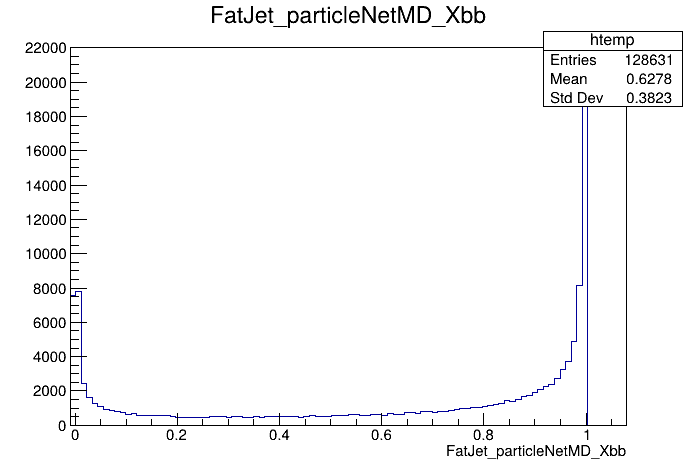

In [3]:
#Disegnino che non fa mai male
c=ROOT.TCanvas()
mytree.Draw("FatJet_particleNet_mass")
mytree.Draw("FatJet_particleNetMD_Xbb")
#mytree.Draw("FatJet_particleNetMD_Xbb:FatJet_particleNet_mass") 
c.Draw()
%jsroot off

In [4]:
#Importiamo i dati per la massas 25 e applichiamo il filtro
file_25=uproot.open("Dati/Tprime_tAq_1800_MH25_LH_2017.root")
tree_25=file_25["Events"]
branches_25=["FatJet_particleNet_mass", "FatJet_particleNetMD_Xbb", "FatJet_particleNetMD_QCD"]
events_25=tree_25.arrays(branches_25, library="ak")
Xbb_25=events_25["FatJet_particleNetMD_Xbb"]
QCD_25=events_25["FatJet_particleNetMD_QCD"]      
#filter=FatJet_particleNetMD_Xbb/(FatJet_particleNetMD_QCD+FatJet_particleNetMD_Xbb) >= 0.98
#Questo è il filtro datoci da Carlo (Chiedere al prof cos'è QCD)
filtro_25=Xbb_25/(QCD_25+Xbb_25) >= 0.98
dati_FatJet_25=tree_25.arrays("FatJet_particleNet_mass", library="ak", cut=filtro_25)
#Otteniamo un array piatto col quale possiamo lavorare
dati_piatti_25=ak.flatten(dati_FatJet_25["FatJet_particleNet_mass"])    

/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


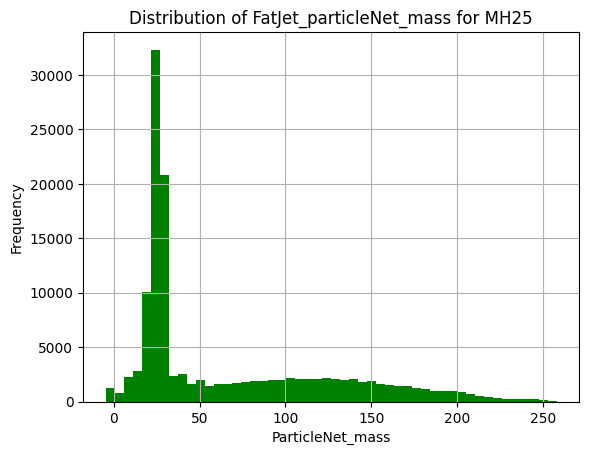

<Figure size 640x480 with 0 Axes>

In [5]:
#Istogramma per la massa 25
plt.figsize=(12,10)
plt.hist(dati_piatti_25, bins=50, histtype="stepfilled", color="green", alpha=1)
plt.xlabel("ParticleNet_mass")
plt.ylabel("Frequency")
plt.title("Distribution of FatJet_particleNet_mass for MH25")
plt.grid()
plt.show()  

plt.savefig("Istogramma_FatJet_Mass_25.png")

In [6]:
#Stessa cosa per la massa 50
file_50=uproot.open("Dati/Tprime_tAq_1800_MH50_LH_2017.root")
tree_50=file_50["Events"]
branches_50=["FatJet_particleNet_mass", "FatJet_particleNetMD_Xbb", "FatJet_particleNetMD_QCD"]
events_50=tree_50.arrays(branches_50, library="ak")
Xbb_50=events_50["FatJet_particleNetMD_Xbb"]
QCD_50=events_50["FatJet_particleNetMD_QCD"]
filtro_50=Xbb_50/(QCD_50+Xbb_50) >= 0.98
dati_FatJet_50=tree_50.arrays("FatJet_particleNet_mass", library="ak", cut=filtro_50)
dati_piatti_50=ak.flatten(dati_FatJet_50["FatJet_particleNet_mass"])




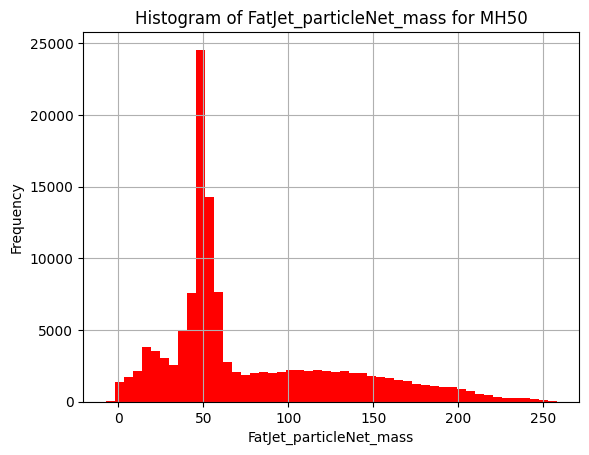

<Figure size 640x480 with 0 Axes>

In [7]:
#Istogramma per la massa 50
plt.figsize=(12,10)
plt.hist(dati_piatti_50, bins=50, histtype="barstacked", color="red", alpha=1)
plt.xlabel("FatJet_particleNet_mass")
plt.ylabel("Frequency")
plt.title("Histogram of FatJet_particleNet_mass for MH50")
plt.grid()
plt.show()  

plt.savefig("Istogramma_FatJet_Mass_50.png")

In [8]:
#Stessa cosa per la massa 75
file_75=uproot.open("Dati/Tprime_tAq_1800_MH75_LH_2017.root")
tree_75=file_75["Events"]
branches_75=["FatJet_particleNet_mass", "FatJet_particleNetMD_Xbb", "FatJet_particleNetMD_QCD"]
events_75=tree_75.arrays(branches_75, library="ak")
Xbb_75=events_75["FatJet_particleNetMD_Xbb"]
QCD_75=events_75["FatJet_particleNetMD_QCD"]
filtro_75=Xbb_75/(QCD_75+Xbb_75) >= 0.98
dati_FatJet_75=tree_75.arrays("FatJet_particleNet_mass", library="ak", cut=filtro_75)
dati_piatti_75=ak.flatten(dati_FatJet_75["FatJet_particleNet_mass"])  


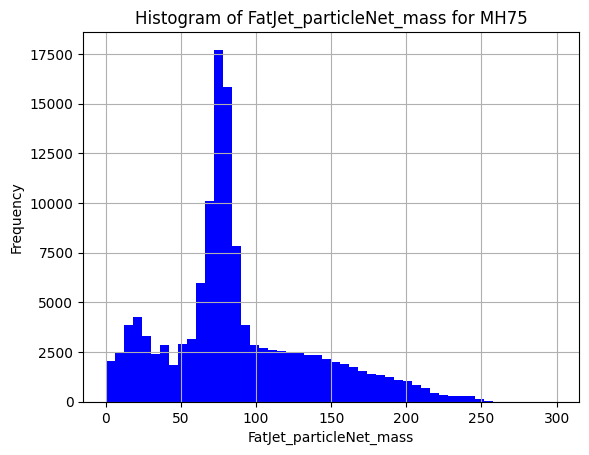

<Figure size 640x480 with 0 Axes>

In [9]:
#Istogramma per la massa 75
plt.figsize=(12,10)
plt.hist(dati_piatti_75, bins=50, range=(0,300), histtype="barstacked", color="blue", alpha=1)
plt.xlabel("FatJet_particleNet_mass")
plt.ylabel("Frequency")
plt.title("Histogram of FatJet_particleNet_mass for MH75")
plt.grid()
plt.show()
plt.savefig("Istogramma_FatJet_Mass_75.png")    


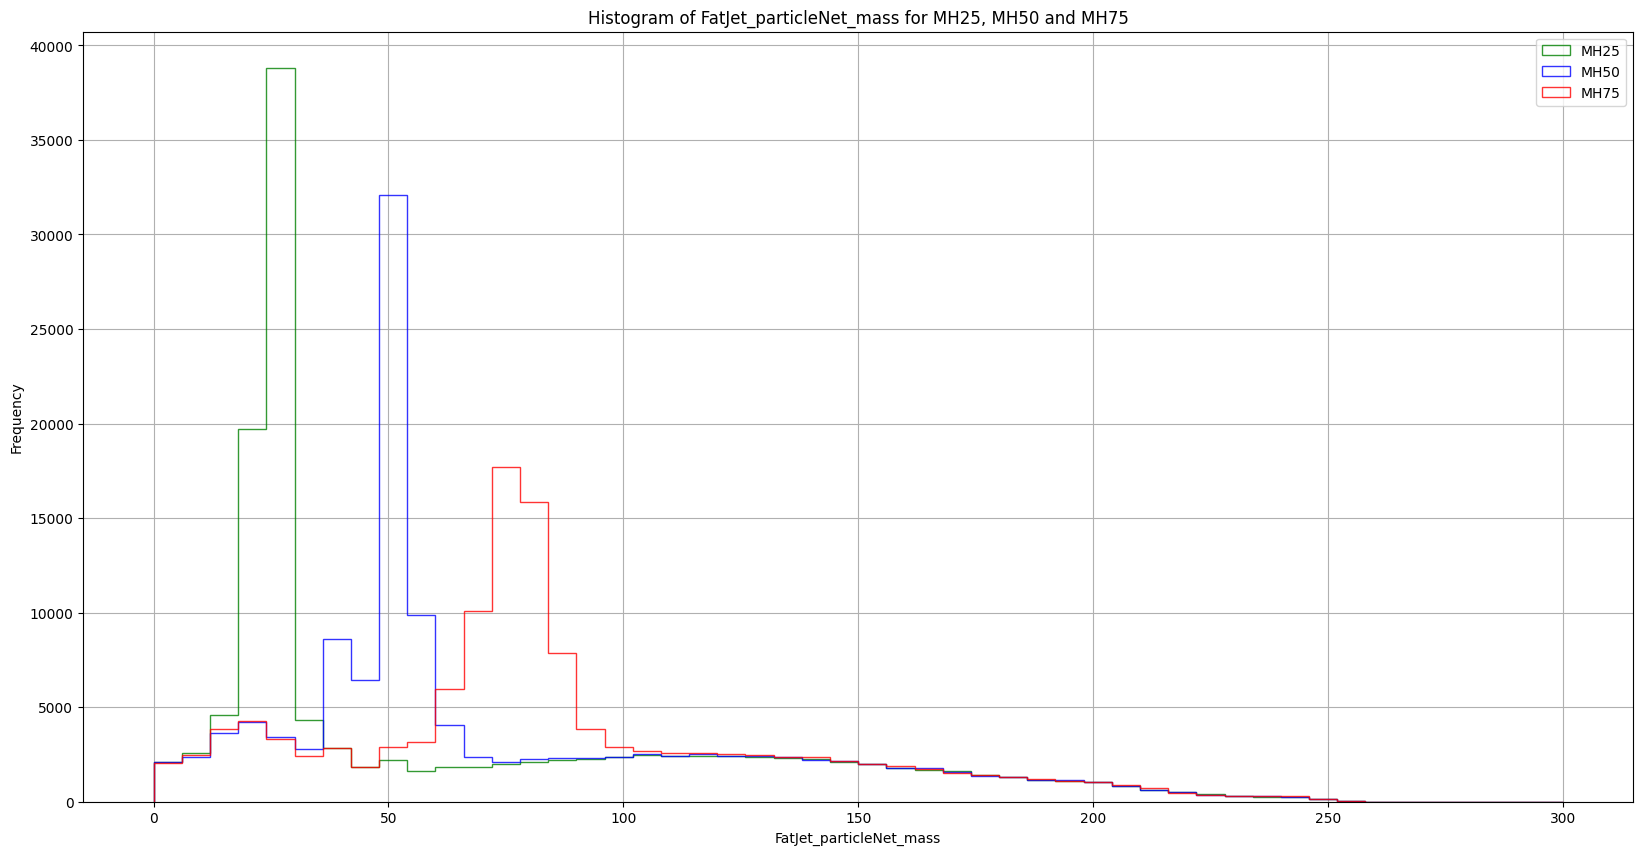

<Figure size 640x480 with 0 Axes>

In [10]:
#Istogramma per tutte e tre le masse
fig, ax = plt.subplots(figsize=(20, 10))
ax.hist(dati_piatti_25, bins=50, range=(0,300), histtype="step", color="green", alpha=0.8, label="MH25")
ax.hist(dati_piatti_50, bins=50, range=(0,300), histtype="step", color="blue", alpha=0.8, label="MH50")
ax.hist(dati_piatti_75, bins=50, range=(0,300), histtype="step", color="red", alpha=0.8, label="MH75")
ax.set_xlabel("FatJet_particleNet_mass")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of FatJet_particleNet_mass for MH25, MH50 and MH75")
ax.legend()
ax.grid()
    

plt.show()
plt.savefig("Istogramma_FatJet_Mass_25_50_75.png")
#L'istogramma è molto carino 
